In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [4]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-DEG-res0.50.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 2000
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch', 'leiden_res_0.50'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res_0.50', 'log1p', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
# Selecting the leiden key
leiden_key = "leiden_res_0.50"
rank_genes_key = "rank_genes_groups"

In [6]:
# Save the dataframe to a CSV file
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{leiden_key}.csv"
deg_results = pd.read_csv(output_path)
deg_results.head()

,0,1,2,3,4
0,Egr1,Gm34455,Uty,Xist,Ccl4
1,Nfkbia,Polg2,Nrgn,Hist1h2bc,Csf1
2,Nfkbiz,Gadd45g,Camk2n1,Csmd3,Ccl3
3,Ier2,Chka,Ddx3y,Hist1h1d,Slc15a3
4,Tnfaip3,Milr1,Camk2a,Hist1h1c,Myo1e


### UMAP: clusters

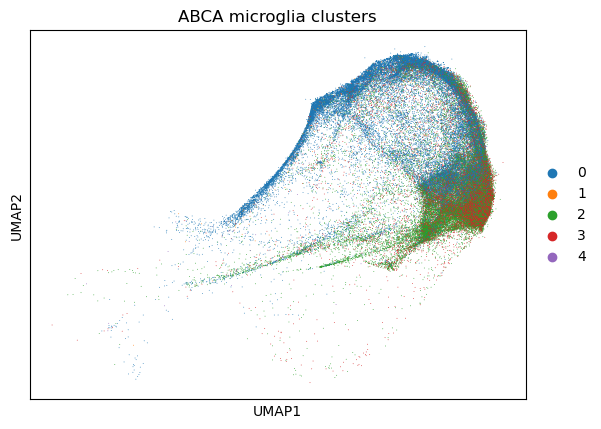

In [8]:
sc.pl.umap(adata, color=leiden_key, title="ABCA microglia clusters")

### MA plot

In [9]:
from scipy import sparse

def ma_plot_with_custom_labels(
    adata,
    target_class,
    groupby="class",
    rank_genes_key = "rank_genes_groups",
    logfc_thresh=0.5,
    fdr_thresh=0.05,
    use_raw_if_available=True,
    pseudocount=1.0,
    label_genes=None,
    save_path=None,
    figsize=(6, 5)
):

    # 1) Extract DE results for the target class
    rg = adata.uns.get(rank_genes_key, None)
    if rg is None:
        raise ValueError(f"{rank_genes_key} results not found in adata.uns.")

    if target_class not in list(rg["names"].dtype.names):
        raise ValueError(f"'{target_class}' not found in rank_genes_groups names.")

    gene_names = rg["names"][target_class]           
    logfc_vals = rg["logfoldchanges"][target_class]  
    pvals_adj   = rg["pvals_adj"][target_class]       

    df = pd.DataFrame({
        "gene":   gene_names,
        "log2FC": logfc_vals,
        "p_adj":  pvals_adj
    }).set_index("gene")

    # 2) Pull expression matrix (raw or normalized)
    if use_raw_if_available and adata.raw is not None:
        expr_matrix = adata.raw.X.copy()
        var_names    = adata.raw.var_names
    else:
        expr_matrix = adata.X.copy()
        var_names    = adata.var_names

    if sparse.issparse(expr_matrix):
        expr_matrix = expr_matrix.toarray()

    expr_df = pd.DataFrame(expr_matrix, index=adata.obs_names, columns=var_names)

    # 3) Determine which cells are in target_class
    if groupby not in adata.obs.columns:
        raise ValueError(f"Column '{groupby}' not found in adata.obs.")
    is_target = adata.obs[groupby] == target_class
    if is_target.sum() == 0:
        raise ValueError(f"No cells labeled '{target_class}' in adata.obs['{groupby}'].")

    # 4) Compute log₂ expression for each gene in each cell
    if use_raw_if_available and adata.raw is not None:
        log_expr_df = np.log2(expr_df + pseudocount)
    else:
        log_expr_df = expr_df.copy()

    mean_target = log_expr_df.loc[is_target, :].mean(axis=0)
    mean_rest   = log_expr_df.loc[~is_target, :].mean(axis=0)

    # 5) Build A (average) and M (log₂FC) for genes present in DE results
    common_genes = df.index.intersection(var_names)
    if len(common_genes) == 0:
        raise ValueError("No overlap between DE genes and expression var_names.")

    A_vals = 0.5 * (mean_target.loc[common_genes] + mean_rest.loc[common_genes])
    M_vals = df.loc[common_genes, "log2FC"]
    P_vals = df.loc[common_genes, "p_adj"]

    plot_df = pd.DataFrame({
        "A":     A_vals,
        "M":     M_vals,
        "p_adj": P_vals
    })

    # 6) Identify “significant” genes
    sig_mask = (plot_df["p_adj"] < fdr_thresh) & (plot_df["M"].abs() > logfc_thresh)

    # 7) Plot the MA plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(
        plot_df.loc[~sig_mask, "A"],
        plot_df.loc[~sig_mask, "M"],
        c="lightgray", s=10, alpha=0.6, label="Not significant"
    )
    ax.scatter(
        plot_df.loc[sig_mask, "A"],
        plot_df.loc[sig_mask, "M"],
        c="crimson", s=14, label="Significant"
    )

    # 8) Draw horizontal lines at ±log₂ fold-change threshold
    ax.axhline(+logfc_thresh, color="green", ls="--", lw=1)
    ax.axhline(-logfc_thresh, color="green", ls="--", lw=1)

    # Annotate those threshold lines
    x_limits = ax.get_xlim()
    y_limits = ax.get_ylim()
    vert_offset = 0.01 * (y_limits[1] - y_limits[0])

    ax.text(
        x_limits[0],
        logfc_thresh + vert_offset,
        f"+{logfc_thresh}",
        color="green", va="bottom", ha="right"
    )
    ax.text(
        x_limits[0],
        -logfc_thresh - vert_offset,
        f"-{logfc_thresh}",
        color="green", va="top", ha="right"
    )

    ax.set_xlabel("Average expression (log₂ scale)")
    ax.set_ylabel("Log₂ Fold Change")
    ax.set_title(f"MA plot: {target_class} vs. rest")
    ax.legend(frameon=False)

    # 9) If the user provided a list of genes to label, annotate them
    if label_genes is not None:
        # Only keep those genes that actually appear in plot_df
        genes_present = [g for g in label_genes if g in plot_df.index]
        missing = [g for g in label_genes if g not in plot_df.index]
        if missing:
            print(f"Warning: these requested genes were not found in DE results and won’t be labeled: {missing}")

        for gene in genes_present:
            x0 = plot_df.loc[gene, "A"]
            y0 = plot_df.loc[gene, "M"]
            ax.text(
                x0,
                y0 + vert_offset,
                gene,
                fontsize=8,
                ha="center",
                color="darkred"
            )

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

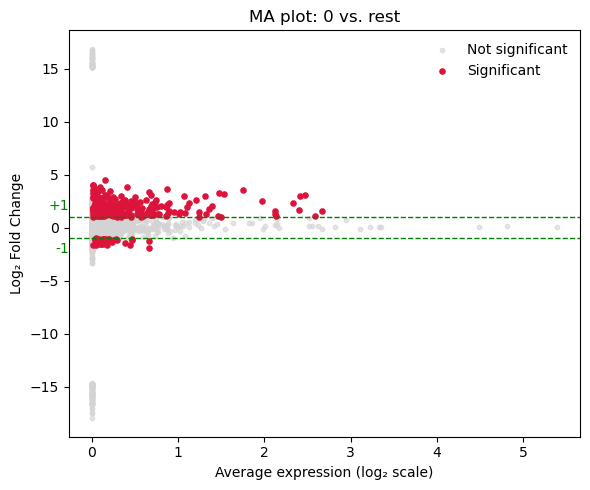

In [14]:
target_class = "0"
ma_plot_with_custom_labels(
    adata,
    target_class=target_class,  # or whatever cluster name you used
    groupby=leiden_key,
    rank_genes_key=rank_genes_key,
    logfc_thresh=1,
    fdr_thresh=0.01,
    use_raw_if_available=False,    # if adata.raw has raw counts
    pseudocount=1.0,              # used only if pulling from adata.raw
    # label_genes = ["C1ql3", "Cck", "Tafa1"],
    save_path = f"figures/ma_plot_ABCA_MG_{target_class}.svg",
    figsize=(6,5)
)

### Heatmap: scaled mean expression

In [17]:
def plot_top_degs_heatmap(
    adata,
    deg_results,
    group_by="class",
    n_genes=5,
    scale=True,
    figsize=(10, 8),
    cmap="vlag",
    save_path=None
):
    """
    Plot a heatmap of mean expression of top n DEGs per class.
    Args:
        adata: AnnData object.
        deg_results: DataFrame, columns=classes, rows=ranked genes.
        group_by: str, column in adata.obs for cell classes.
        n_genes: int, number of top DEGs per class.
        scale: bool, whether to z-score scale genes across classes.
        figsize: tuple, figure size.
        cmap: str, colormap.
        save_path: str or None, path to save figure.
    """
    # 1. Get unique top genes across all classes
    top_genes = []
    for col in deg_results.columns:
        top_genes.extend(deg_results[col].dropna().head(n_genes).tolist())
    top_genes = list(dict.fromkeys(top_genes))  # preserve order, remove duplicates

    # 2. Compute mean expression per class for these genes
    class_labels = adata.obs[group_by].unique()
    class_labels = sorted(class_labels)
    expr = adata[:, top_genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr_df = pd.DataFrame(expr, index=adata.obs[group_by], columns=top_genes)
    mean_expr = expr_df.groupby(level=0).mean().reindex(class_labels)

    # 3. Optionally scale (z-score) genes across classes
    if scale:
        mean_expr = (mean_expr - mean_expr.mean(axis=0)) / mean_expr.std(axis=0)
        vmin, vmax = -2, 2
    else:
        vmin = vmax = None

    # 4. Plot clustered heatmap
    g = sns.clustermap(
        mean_expr.T,
        figsize=figsize,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        row_cluster=True,
        col_cluster=True,
        xticklabels=True,
        yticklabels=False,
        cbar_kws={"label": "Scaled mean expression" if scale else "Mean expression"}
    )
    g.ax_heatmap.set_xlabel("Clusters")
    
    g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), 
    rotation=30, 
    ha='right')
    g.ax_heatmap.set_ylabel("Gene")
    
    plt.title("")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

/tmp/ipykernel_315935/3903051456.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expr_df.groupby(level=0).mean().reindex(class_labels)


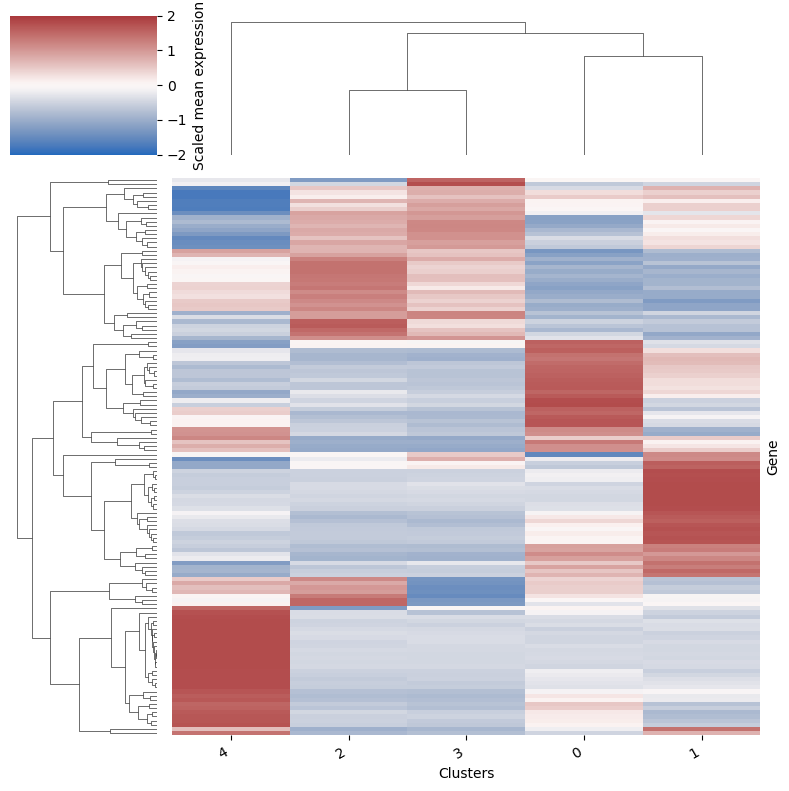

In [20]:
# Example usage:
plot_top_degs_heatmap(
    adata,
    deg_results,
    group_by=leiden_key,
    n_genes=30,
    scale=True,
    figsize=(8, 8),
    cmap="vlag",
    save_path="figures/top_degs_heatmap_ABCA_MG.svg"
)

### Dot plot: log fold changes

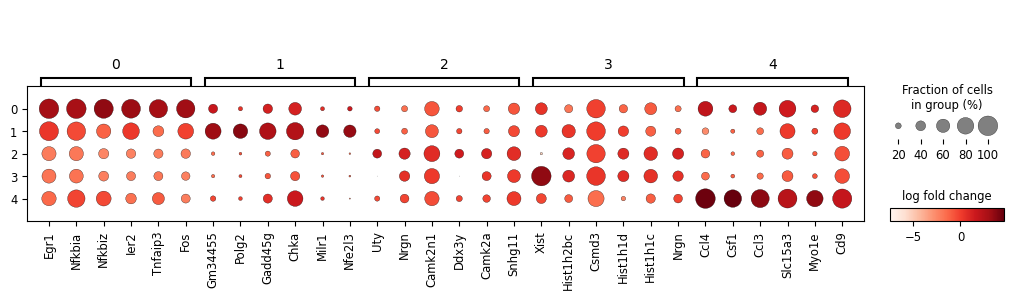

In [25]:
sc.pl.rank_genes_groups_dotplot(adata,
                                n_genes=6,
                                dendrogram=False,
                                values_to_plot="logfoldchanges",
                                key = rank_genes_key,
                                # cmap = "viridis"
                                # min_logfoldchange=1,
                                save="ABCA_MG.svg"
                                )

### Track plot

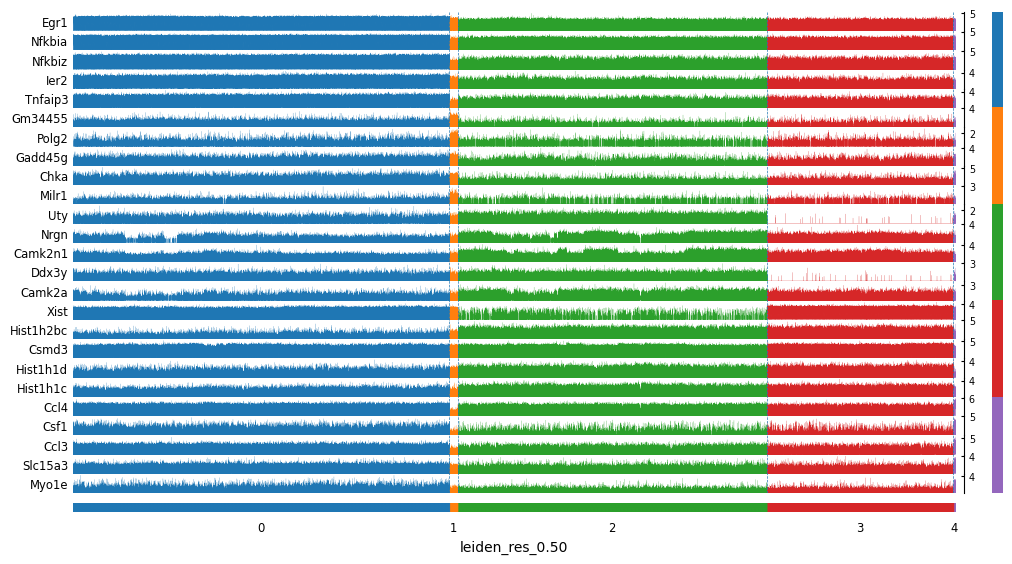

In [26]:
sc.pl.rank_genes_groups_tracksplot(adata,
                                   # groups = ["01 IT-ET Glut"],
                                   n_genes=5,
                                   dendrogram=False,
                                   show = True,
                                   # save="_Isoctx.png",
                                   )

### UMAP: markers

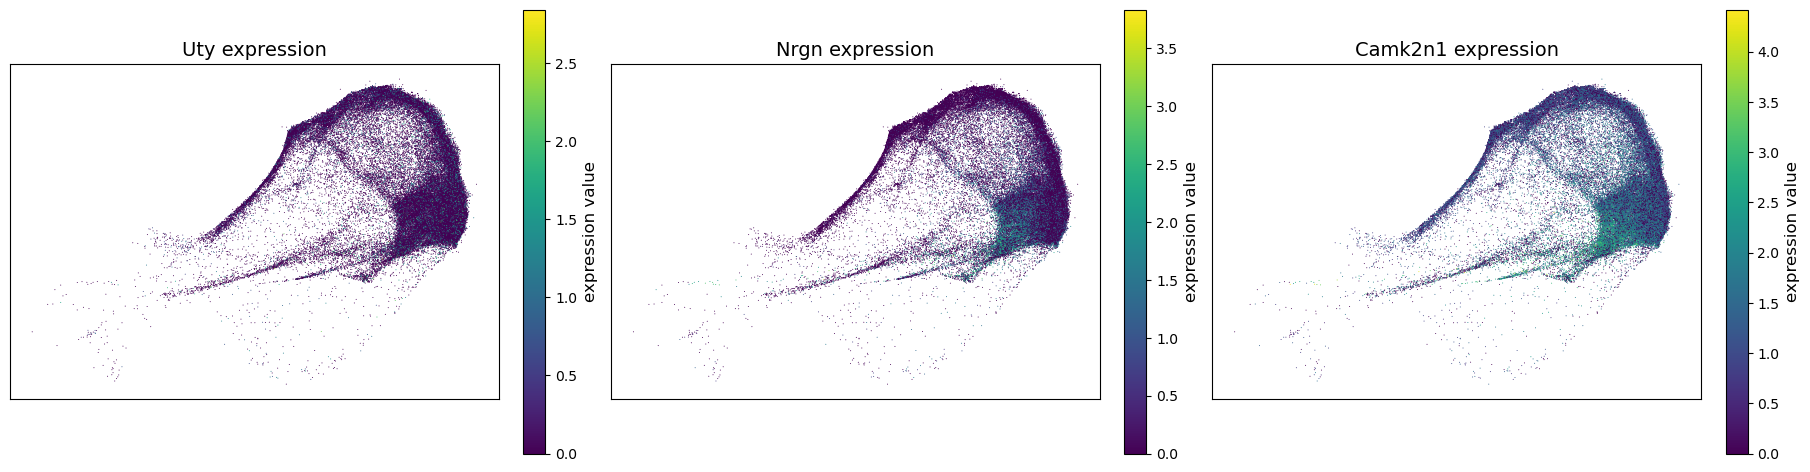

In [27]:
# Select a group and get the top 5 genes
group = "2"
top_genes = deg_results[group].head(3)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.75)
    cbar.set_label("expression value", fontsize=12)  # Change font size here

    # fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"expression value")
    ax.set_title(f"{gene} expression", fontsize = 14) # , marker of \"{group}\"
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# plt.savefig(f"figures/expression_{group}.png", dpi=300, bbox_inches='tight')
plt.show()

### Specificity: Tau score

In [28]:
# Compute Tau scores
def compute_tau_score(adata, cluster_name, n_genes, group_by="class"):
    
    # Get expression matrix for the given cluster
    deg_expression_matrix = pd.DataFrame(
    adata.X.toarray(),  # Convert sparse matrix to dense
    index=adata.obs[group_by],  # Use the group_by column as the index
    columns=adata.var.index  # Use gene names as columns
    )

    # Select the top genes for the given cluster
    top_genes = deg_results[cluster_name].head(n_genes)

    # Compute Tau score for each gene
    tau_scores = {}
    for gene in top_genes:
        expression_values = deg_expression_matrix[gene]
        max_expression = expression_values.max()
        if max_expression > 0:
            normalized_expression = 1 - (expression_values / max_expression)
            tau_score = normalized_expression.sum() / (len(expression_values) - 1)
            tau_scores[gene] = tau_score
        else:
            tau_scores[gene] = 0

    # Convert to DataFrame
    tau_scores_df = pd.DataFrame(list(tau_scores.items()), columns=["Gene", "Tau Score"])
    return tau_scores_df

In [29]:
# Prompt for cluster name and number of genes
cluster_name = "0"  # Example cluster name
n_genes = 5

# Compute Tau scores
tau_scores_df = compute_tau_score(adata, cluster_name, n_genes, group_by=leiden_key)
print(tau_scores_df)

      Gene  Tau Score
0     Egr1   0.544722
1   Nfkbia   0.534910
2   Nfkbiz   0.666678
3     Ier2   0.703020
4  Tnfaip3   0.730659


### Thresholding markers

In [40]:
def filter_degs_all_classes(adata, logfc_thresh=1.0, fdr_thresh=0.05, absolute_logfc=True):
    """
    Return a dictionary of DataFrames of DEGs for all classes passing logFC and FDR thresholds.
    Args:
        adata: AnnData object with rank_genes_groups results.
        logfc_thresh: Minimum absolute log2 fold change.
        fdr_thresh: Maximum adjusted p-value (FDR).
    Returns:
        Dictionary with class names as keys and DataFrames as values.
    """
    rg = adata.uns["rank_genes_groups"]
    classes = rg["names"].dtype.names
    degs_dict = {}
    for cls in classes:
        genes = rg["names"][cls]
        logfc = rg["logfoldchanges"][cls]
        pvals_adj = rg["pvals_adj"][cls]
        df = pd.DataFrame({
            "gene": genes,
            "logFC": logfc,
            "pval_adj": pvals_adj
        })
        if absolute_logfc:
            mask = (df["pval_adj"] < fdr_thresh) & (abs(df["logFC"]) > logfc_thresh)
        else:
            mask = (df["pval_adj"] < fdr_thresh) & (df["logFC"] > logfc_thresh)
        degs_dict[cls] = df[mask].reset_index(drop=True)
    return degs_dict

In [42]:
sig_DEGs_dict = filter_degs_all_classes(
    adata,
    logfc_thresh=1.0,
    fdr_thresh=0.05,
    absolute_logfc=False
    )

for key, df in sig_DEGs_dict.items():
    print(f"Cluster {key}: {len(df)} significant DEGs")
# print(sig_DEGs_dict["1"].shape)
# sig_DEGs_dict["1"].head(20)

Cluster 0: 222 significant DEGs
Cluster 1: 78 significant DEGs
Cluster 2: 12 significant DEGs
Cluster 3: 2 significant DEGs
Cluster 4: 115 significant DEGs


In [33]:
sig_DEGs_dict["3"].head()

,gene,logFC,pval_adj
0,Xist,3.598463,0.000000
1,Gpr88,1.150621,0.000042


### Heatmap: Jaccard index

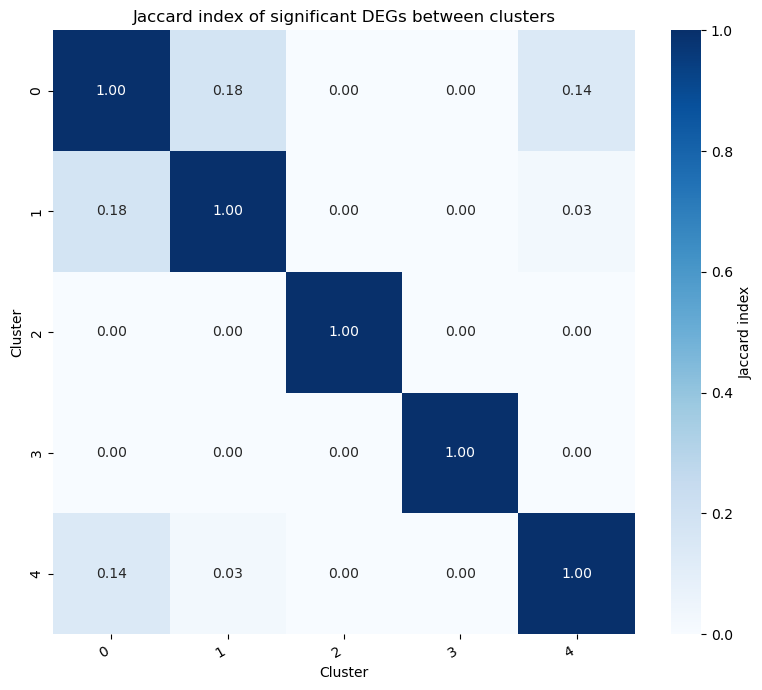

In [35]:
# Compute Jaccard index heatmap between marker sets from sig_DEGs_dict

# Get cluster names and marker sets
clusters = list(sig_DEGs_dict.keys())
n_clusters = len(clusters)
marker_sets = {cls: set(df["gene"]) for cls, df in sig_DEGs_dict.items()}

# Compute Jaccard index matrix
jaccard_matrix = np.zeros((n_clusters, n_clusters), dtype=float)
for i, cls1 in enumerate(clusters):
    for j, cls2 in enumerate(clusters):
        set1 = marker_sets[cls1]
        set2 = marker_sets[cls2]
        union = set1 | set2
        intersection = set1 & set2
        if len(union) == 0:
            jaccard_matrix[i, j] = np.nan
        else:
            jaccard_matrix[i, j] = len(intersection) / len(union)

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    jaccard_matrix,
    xticklabels=clusters,
    yticklabels=clusters,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Jaccard index"}
)
plt.xticks(rotation=30, ha="right")
plt.title("Jaccard index of significant DEGs between clusters")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("figures/jaccard_index_heatmap_ABCA_MG.svg", dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# # Number of top DEGs to consider
# top_n = 100

# # Get class names and top-N gene sets
# classes = deg_results.columns.tolist()
# n_classes = len(classes)
# deg_sets = {cls: set(deg_results[cls].dropna().head(top_n)) for cls in classes}

# # Compute Jaccard index matrix
# fraction_matrix = np.zeros((n_classes, n_classes), dtype=float)

# for i, cls1 in enumerate(classes):
#     for j, cls2 in enumerate(classes):
#         set1 = deg_sets[cls1]
#         set2 = deg_sets[cls2]
#         union_size = len(set1 | set2)
#         if union_size == 0:
#             fraction_matrix[i, j] = np.nan  # avoid division by zero
#         else:
#             fraction_matrix[i, j] = len(set1 & set2) / union_size

# # Plot heatmap
# plt.figure(figsize=(8, 7))
# sns.heatmap(
#     fraction_matrix,
#     xticklabels=classes,
#     yticklabels=classes,
#     cmap="Blues",
#     annot=False,
#     fmt=".2f",
#     cbar_kws={"label": f""}
# )
# plt.xticks(rotation=30, ha="right")
# plt.title(f"Fractional overlap (Jaccard index) of top {top_n} DEGs")
# plt.xlabel("")
# plt.ylabel("")
# plt.tight_layout()
# # plt.savefig(f"figures/jaccard_index_heatmap_{select_region}.svg")
# plt.show()

### Heatmap: marker correlation

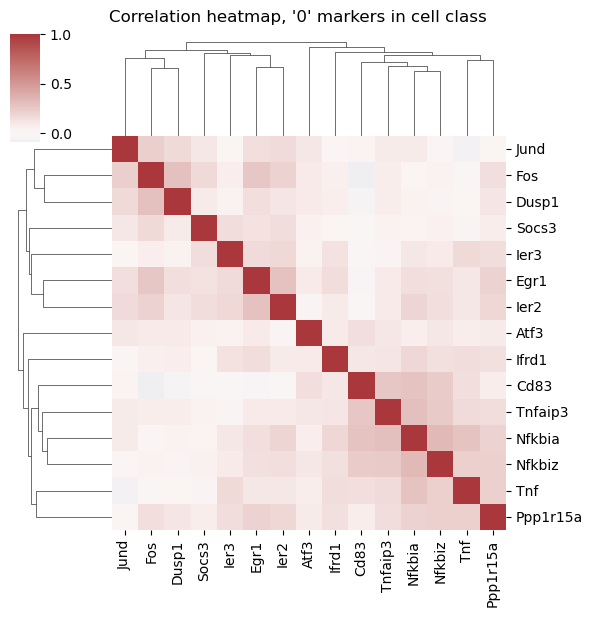

In [36]:
# Option: restrict correlation to cells of a specific class
restrict_to_class = True  # Set to True to use only cells of the target class
target_class = "0"
all_genes = False
select_genes = deg_results[target_class].head(15)
group_by = leiden_key  # Column in adata.obs to group cells by class

# Extract expression matrix for significant DEGs
if all_genes:
    genes = adata.var_names.tolist()
elif select_genes is not None:
    genes = select_genes.tolist()
else:
    genes = sig_DEGs_dict[target_class]["gene"].tolist()


if restrict_to_class:
    cell_mask = adata.obs[group_by] == target_class
    expr_subset = adata[cell_mask, genes].X
    if hasattr(expr_subset, "toarray"):
        expr_subset = expr_subset.toarray()
    corr_matrix = np.corrcoef(expr_subset.T)
    title = f"Correlation heatmap, '{target_class}' markers in cell class"
else:
    expr = adata[:, genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    corr_matrix = np.corrcoef(expr.T)
    title = f"Correlation heatmap of \"{target_class}\" markers"

sns.clustermap(
    corr_matrix,
    row_cluster=True,
    col_cluster=True,
    xticklabels=genes,
    yticklabels=genes,
    cmap="vlag",
    center=0,
    figsize=(6, 6)
)
plt.suptitle(title, y=1.02)
# plt.savefig(f"figures/heatmap_correlation_{target_class}.svg")
plt.show()

### Biological relevance: GO enrichment analysis

In [37]:
from gprofiler import GProfiler

# Parameters
organism = "mmusculus"  # Use "hsapiens" for human

gp = GProfiler(return_dataframe=True)
go_enrichment_results = []

for cluster, df in sig_DEGs_dict.items():
    # Use all marker genes for this cluster
    marker_genes = df["gene"].dropna().tolist()
    if not marker_genes:
        print(f"Skipping cluster {cluster}: no markers found.")
        continue

    # Run GO enrichment
    enrichment_result = gp.profile(
        organism=organism,
        query=marker_genes,
        sources=["GO:BP"]  # Biological Process
    )
    enrichment_result["cluster"] = cluster
    go_enrichment_results.append(enrichment_result)

# Combine all results into a single DataFrame
go_results_df = pd.concat(go_enrichment_results, ignore_index=True)
go_results_df.head()

/tmp/ipykernel_315935/3715912941.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  go_results_df = pd.concat(go_enrichment_results, ignore_index=True)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0051239,regulation of multicellular organismal process,5.196808e-29,True,"""Any process that modulates the frequency, rat...",3145,189,87,26963,0.460317,0.027663,query_1,"[GO:0032501, GO:0050789]",0
1,GO:BP,GO:0010604,positive regulation of macromolecule metabolic...,1.111109e-25,True,"""Any process that increases the frequency, rat...",3404,189,86,26963,0.455026,0.025264,query_1,"[GO:0009893, GO:0043170, GO:0060255]",0
2,GO:BP,GO:0048522,positive regulation of cellular process,2.009643e-25,True,"""Any process that activates or increases the f...",6243,189,115,26963,0.608466,0.018421,query_1,"[GO:0009987, GO:0048518, GO:0050794]",0
3,GO:BP,GO:0006950,response to stress,2.612863e-25,True,"""Any process that results in a change in state...",3966,189,92,26963,0.486772,0.023197,query_1,[GO:0050896],0
4,GO:BP,GO:0048518,positive regulation of biological process,1.142187e-24,True,"""Any process that activates or increases the f...",6584,189,117,26963,0.619048,0.017770,query_1,"[GO:0008150, GO:0050789]",0


In [ ]:
# from gprofiler import GProfiler

# # Parameters
# n_top_genes = 100  # Number of top DEGs to include per cluster
# organism = "mmusculus"  # Mouse gene symbols (use "hsapiens" for human)

# # Initialize g:Profiler client
# gp = GProfiler(return_dataframe=True)

# # Store all results
# go_enrichment_results = []

# # Loop through each cluster in the DEG results
# for cluster in deg_results.columns:
#     # Get the top n DEGs for the cluster
#     top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
    
#     # Skip clusters with no DEGs
#     if not top_genes:
#         print(f"Skipping {cluster}: no DEGs found.")
#         continue
    
#     # Perform GO enrichment analysis
#     enrichment_result = gp.profile(
#         organism=organism,
#         query=top_genes,
#         sources=["GO:BP"]  # Biological Process, Molecular Function, Cellular Component, "GO:MF", "GO:CC"
#     )
    
#     # Add cluster name to the results
#     enrichment_result["cluster"] = cluster
#     go_enrichment_results.append(enrichment_result)

# # Combine all results into a single DataFrame
# go_results_df = pd.concat(go_enrichment_results, ignore_index=True)

# # Display the first few rows of the results
# go_results_df.head(2)

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0006950,response to stress,3.883974e-23,True,"""Any process that results in a change in state...",3966,97,60,26963,0.618557,0.015129,query_1,[GO:0050896],0
1,GO:BP,GO:0010604,positive regulation of macromolecule metabolic...,1.079128e-22,True,"""Any process that increases the frequency, rat...",3404,97,56,26963,0.577320,0.016451,query_1,"[GO:0009893, GO:0043170, GO:0060255]",0


In [58]:
# go_results_df.to_csv(
#     "outputs/GO_DEA.csv",
#     index=False
# )

In [38]:
def plot_go_dotplot(go_results_df, top_n=3, classes_on_x_axis=True, save_path=None):
    # ---------------------------------------------
    # Select top N enriched terms per cluster
    # ---------------------------------------------
    top_terms_df = (
        go_results_df
        .sort_values("p_value")
        .groupby("cluster")
        .head(top_n)
        .copy()
    )

    # Shorten term names for better plotting
    top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
    top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

    # Optional: sort GO terms by frequency of appearance across clusters
    term_order = (
        top_terms_df["term_display"]
        .value_counts()
        .index.tolist()
    )

    # ---------------------------------------------
    # Axes assignment based on flag
    # ---------------------------------------------
    if classes_on_x_axis:
        x, y = "cluster", "term_display"
        figsize = (10, max(5, 0.4 * len(term_order)))
        xlabel, ylabel = "", ""  # optional: customize
        xtick_rotation = 45
    else:
        x, y = "term_display", "cluster"
        figsize = (max(10, 0.4 * len(term_order)), 8)
        xlabel, ylabel = "", ""
        xtick_rotation = 90

    # ---------------------------------------------
    # Create the Dot Plot
    # ---------------------------------------------
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=top_terms_df,
        x=x,
        y=y,
        size="intersection_size",
        hue="-log10(p)",
        sizes=(30, 300),
        palette="viridis",
        edgecolor="black",
        alpha=0.8,
    )

    plt.xticks(rotation=xtick_rotation, ha="right" if classes_on_x_axis else "center")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Top {top_n} enriched GO terms per cell class")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

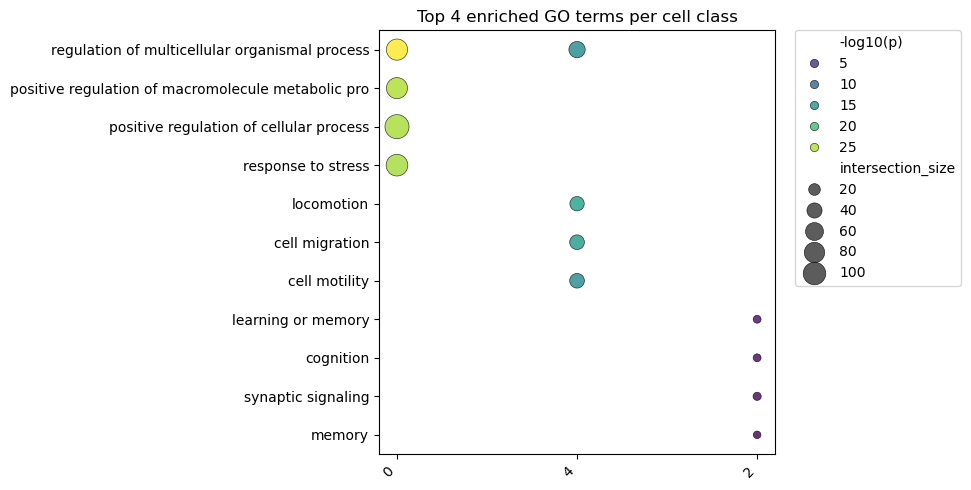

In [45]:
plot_go_dotplot(go_results_df,
                top_n=4,
                save_path="figures/go_dotplot_ABCA_MG.svg",
                classes_on_x_axis=True)  # cluster on y-axis

## Literature miceroglia signatures

In [122]:
microglia_gene_signatures = {
    "homeostatic": [
        "P2ry12", "Tmem119", "Cx3cr1", "Siglech", "Hexb", "Fcrls", 
        "Gpr34", "Olfml3", "Sall1", "Csf1r", "Cst3"
    ],
    "dam_stage1_upregulated": [
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd"
    ],
    "dam_stage2_upregulated": [
        "Trem2", "Axl", "Itgax", "Cd9", "Cd63", "Csf1", "Ccl6", "C3",
        "Igf1", "Lyz2", "Cybb", "Lpl", "Cst7", "Ctsl", "Ctsz", 
        "Clec7a", "Lilrb4a", "Gpnmb", "Spp1", "Timp2"
    ],
    "dam_all_upregulated": [ # A combined list of all upregulated DAM genes
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd", "Fth1", "Trem2", "Axl", "Itgax", 
        "Cd9", "Cd63", "Csf1", "Ccl6", "C3", "Igf1", "Lyz2", "Cybb", "Lpl", 
        "Cst7", "Ctsl", "Ctsz", "Clec7a", "Lilrb4a", "Gpnmb", "Spp1", "Timp2"
    ],
    "dam_downregulated": [ # These are essentially homeostatic genes
        "Tmem119", "P2ry12", "P2ry13", "Cx3cr1", "Cst3", "Cd33", "Csf1r"
    ],
    "ifn_response": [ # Type I Interferon Response Microglia
        "Ifit1", "Ifit3", "Ifitm3", "Isg15", "Oasl2", "Ch25h", "Irf7"
    ],
    "mhc_ii": [ # MHC-II Microglia
        "H2-Aa", "H2-Ab1", "H2-Eb1", "Cd74", "Hif1a"
    ],
    "arm": [ # Activated Response Microglia (largely overlaps with DAM)
        "Itgax", "Cst7", "Clec7a", "Cd74", "H2-Aa", "H2-Ab1", "Apoe", "Lpl"
    ],
    "proliferating": [
        "Mki67", "Top2a", "Pcna"
    ],
    "aging_associated": [ # General aging markers, includes ARM/DAM-like and IRM genes
        "Ccl3", "Ccl4", "Il1b", "Itgax", "Spp1", "Apoe", "Ifitm3", "Irf7",
        "Lpl", "Lgals3", "Cst7", "Clec7a", "H2-Aa", "H2-Ab1"
    ],
    "lps_induced_upregulated": [ # Acute inflammation model
        "Rplp0", "Rps2", "Cd52", "Cd63", "Ctsl", "Manf", "Pdia4", "Calm1", 
        "Fth1", "C5ar1", "Hacd2", "Gnl3"
    ],
    "nerve_injury_associated": [ # Markers associated with chronic nerve injury contexts
        "Apoe", "Spp1", "Lpl", "Atf3", "Gfap", "Vim", "Itgax", "Lgals3"
    ],
    "pan_microglial_markers": [ # General markers for identifying microglia
        "Itgam", "Aif1", "Cx3cr1", "Csf1r", "Ptprc"
    ]
}

In [123]:
# Check which genes in microglia_gene_signatures are missing from adata.var_names
missing_genes = {}
for signature, genes in microglia_gene_signatures.items():
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        missing_genes[signature] = missing

for signature, genes in missing_genes.items():
    print(f"Signature '{signature}' missing genes in adata: {genes}")

Signature 'dam_stage2_upregulated' missing genes in adata: ['Clec7a']
Signature 'dam_all_upregulated' missing genes in adata: ['Clec7a']
Signature 'arm' missing genes in adata: ['Clec7a']
Signature 'aging_associated' missing genes in adata: ['Clec7a']


In [124]:
def search_genes(keyword, adata):
    """
    Search for genes in adata.var_names containing the given keyword (case-insensitive).
    Returns a list of matching gene names.
    """
    keyword = keyword.lower()
    matches = [gene for gene in adata.var_names if keyword in gene.lower()]
    return matches

In [125]:
# Example usage:
genes_found = search_genes("Hacd2", adata)
print(genes_found)

['Hacd2']


### Heatmap: Jaccard indext

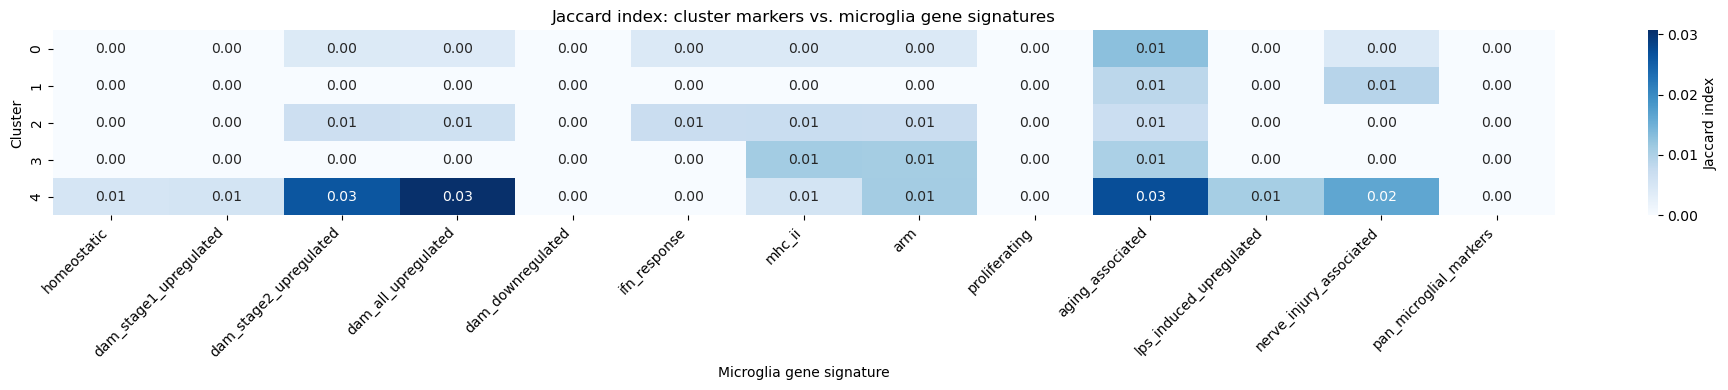

In [132]:
# Compute Jaccard index heatmap between cluster marker sets and microglia gene signatures

# Prepare sets
cluster_names = list(sig_DEGs_dict.keys())
signature_names = list(microglia_gene_signatures.keys())

# Build marker sets for clusters
cluster_marker_sets = {cls: set(df["gene"]) for cls, df in sig_DEGs_dict.items()}
# Build gene sets for signatures (only keep genes present in adata.var_names)
signature_sets = {
    sig: set([g for g in genes if g in adata.var_names])
    for sig, genes in microglia_gene_signatures.items()
}

# Compute Jaccard index matrix (clusters x signatures)
jaccard_mat = np.zeros((len(cluster_names), len(signature_names)), dtype=float)
for i, cls in enumerate(cluster_names):
    for j, sig in enumerate(signature_names):
        set1 = cluster_marker_sets[cls]
        set2 = signature_sets[sig]
        union = set1 | set2
        intersection = set1 & set2
        if len(union) == 0:
            jaccard_mat[i, j] = np.nan
        else:
            jaccard_mat[i, j] = len(intersection) / len(union)

# Plot heatmap
plt.figure(figsize=(1.5 * len(signature_names), 1 + 0.6 * len(cluster_names)))
sns.heatmap(
    jaccard_mat,
    xticklabels=signature_names,
    yticklabels=cluster_names,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Jaccard index"}
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Microglia gene signature")
plt.ylabel("Cluster")
plt.title("Jaccard index: cluster markers vs. microglia gene signatures")
plt.tight_layout()
plt.show()

### Over-Representation Analysis

In [130]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def ora_between_clusters_and_signatures(sig_DEGs_dict, microglia_gene_signatures, background_genes=None, correction_method="fdr_bh"):
    """
    Perform over-representation analysis (Fisher's exact test) between cluster markers and microglia gene signatures.
    Prints warnings for unmatched gene names.
    Returns a DataFrame with results for all cluster-signature pairs, including multiple hypothesis correction.
    """
    results = []
    # Build background gene set
    if background_genes is None:
        marker_genes = set()
        for df in sig_DEGs_dict.values():
            marker_genes.update(df["gene"])
        signature_genes = set(g for genes in microglia_gene_signatures.values() for g in genes)
        background_genes = marker_genes | signature_genes

    for cluster, df in sig_DEGs_dict.items():
        cluster_genes = set(df["gene"])
        for sig_name, sig_genes in microglia_gene_signatures.items():
            sig_genes_set = set(sig_genes)
            unmatched_in_sig = [g for g in sig_genes_set if g not in background_genes]
            unmatched_in_cluster = [g for g in cluster_genes if g not in background_genes]
            if unmatched_in_sig:
                print(f"Signature '{sig_name}' - genes not in background: {unmatched_in_sig}")
            if unmatched_in_cluster:
                print(f"Cluster '{cluster}' - genes not in background: {unmatched_in_cluster}")

            overlap = cluster_genes & sig_genes_set
            a = len(overlap)
            b = len(cluster_genes - sig_genes_set)
            c = len(sig_genes_set - cluster_genes)
            d = len(background_genes - (cluster_genes | sig_genes_set))
            contingency = [[a, b], [c, d]]
            oddsratio, pval = fisher_exact(contingency, alternative="greater")
            results.append({
                "cluster": cluster,
                "signature": sig_name,
                "overlap": a,
                "cluster_size": len(cluster_genes),
                "signature_size": len(sig_genes_set),
                "background_size": 32285, #len(background_genes),
                "oddsratio": oddsratio,
                "pval": pval,
                "overlap_genes": ", ".join(sorted(overlap))
            })
    df_results = pd.DataFrame(results)
    # Multiple hypothesis correction
    if not df_results.empty:
        reject, pvals_corrected, _, _ = multipletests(df_results["pval"], method=correction_method)
        df_results["pval_adj"] = pvals_corrected
        df_results["significant"] = reject
    return df_results

In [129]:
len(adata.var_names)

32285

In [131]:
ora_results_df = ora_between_clusters_and_signatures(sig_DEGs_dict, microglia_gene_signatures)
ora_results_df.sort_values("pval").head(10)

,cluster,signature,overlap,cluster_size,signature_size,background_size,oddsratio,pval,overlap_genes,pval_adj,significant
61,4,aging_associated,5,177,14,32285,1.120801,0.521447,"Ccl3, Ccl4, Itgax, Lgals3, Lpl",1.0,False
63,4,nerve_injury_associated,3,177,8,32285,1.210345,0.529457,"Itgax, Lgals3, Lpl",1.0,False
45,3,mhc_ii,1,86,5,32285,1.302941,0.586644,Cd74,1.0,False
46,3,arm,1,86,8,32285,0.739496,0.757781,Cd74,1.0,False
32,2,mhc_ii,1,134,5,32285,0.742481,0.766399,Cd74,1.0,False
59,4,arm,2,177,8,32285,0.666667,0.804915,"Itgax, Lpl",1.0,False
24,1,nerve_injury_associated,1,103,8,32285,0.592437,0.822823,Atf3,1.0,False
54,4,dam_stage2_upregulated,5,177,20,32285,0.660853,0.850609,"Cd63, Cd9, Csf1, Itgax, Lpl",1.0,False
58,4,mhc_ii,1,177,5,32285,0.500000,0.868316,Hif1a,1.0,False
53,4,dam_stage1_upregulated,1,177,5,32285,0.500000,0.868316,Ctsb,1.0,False


### Gene set scoring

In [133]:
import scanpy as sc

# Score each signature using scanpy's score_genes function
for signature_name, gene_list in microglia_gene_signatures.items():
    # Only keep genes present in adata.var_names
    genes_in_data = [g for g in gene_list if g in adata.var_names]
    if len(genes_in_data) == 0:
        print(f"Signature '{signature_name}': no genes found in adata.var_names, skipping.")
        continue
    sc.tl.score_genes(adata, gene_list=genes_in_data, score_name=f"{signature_name}_score", use_raw=False)
    print(f"Scored signature: {signature_name} ({len(genes_in_data)} genes)")

# The scores are now in adata.obs with columns like 'homeostatic_score', etc.
adata.obs[[f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in adata.obs.columns]].head()

Scored signature: homeostatic (11 genes)
Scored signature: dam_stage1_upregulated (5 genes)
Scored signature: dam_stage2_upregulated (19 genes)
Scored signature: dam_all_upregulated (25 genes)
Scored signature: dam_downregulated (7 genes)
Scored signature: ifn_response (7 genes)
Scored signature: mhc_ii (5 genes)
Scored signature: arm (7 genes)
Scored signature: proliferating (3 genes)
Scored signature: aging_associated (13 genes)
Scored signature: lps_induced_upregulated (12 genes)
Scored signature: nerve_injury_associated (8 genes)
Scored signature: pan_microglial_markers (5 genes)


,homeostatic_score,dam_stage1_upregulated_score,dam_stage2_upregulated_score,dam_all_upregulated_score,dam_downregulated_score,ifn_response_score,mhc_ii_score,arm_score,proliferating_score,aging_associated_score,lps_induced_upregulated_score,nerve_injury_associated_score,pan_microglial_markers_score
cell_label,,,,,,,,,,,,,
TGGATCAGTAACACCT-478_A02-0,1.191589,1.996007,0.488377,0.993610,1.027411,-0.011798,0.084230,0.195934,0.366255,0.185525,0.233373,-0.026463,0.561870
TCACTCGCAAGTTCGT-215_C01-0,1.123275,0.362051,0.044501,0.304007,1.241287,0.000000,-0.140886,-0.130719,-0.105060,-0.239057,-0.056746,-0.310160,0.382745
GAGTGAGTCCTTATCA-472_B05-0,0.185258,1.540480,0.621712,1.063372,0.438663,-0.007974,0.171212,0.225540,0.175412,0.404993,1.095548,0.112115,0.722132
CACGGGTTCATTTCCA-216_D01-0,1.037188,1.035640,0.243774,0.652723,1.181584,-0.028055,-0.206041,-0.181715,-0.060209,-0.297168,0.493370,-0.316217,1.013049
TTTCACATCCGCACTT-171_C01-0,1.202517,1.692286,0.383132,0.880567,1.563253,0.073066,0.055039,0.197579,0.147215,-0.119074,0.778754,-0.029107,0.723411


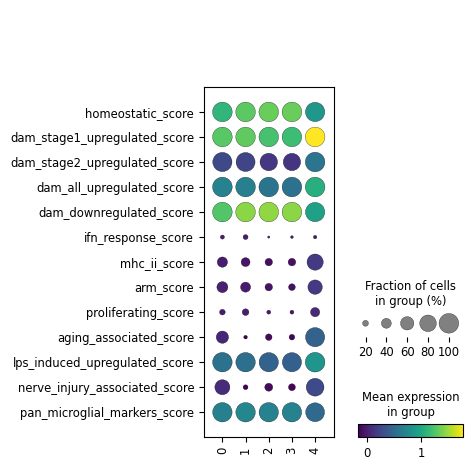

In [134]:
# Visualize gene set scores as a dotplot across clusters
score_cols = [f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in adata.obs.columns]
cluster_col = leiden_key

# Visualize gene set scores as a dotplot across clusters using scanpy's dotplot
sc.pl.dotplot(
    adata,
    var_names=score_cols,  # gene set score columns in .obs
    groupby=cluster_col,
    standard_scale=None,   # do not z-score, show raw scores
    use_raw=False,
    dot_max=None,
    color_map="viridis",
    swap_axes=True,        # signatures on y-axis, clusters on x-axis
    show=True
)

## Modules

In [25]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [26]:
n_top_genes_per_module = 3  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    if module_name == "grey":
        continue  # Skip the grey module
    
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948
3,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
4,ENSMUSG00000112148,MG-M2,brown,0.119674,0.019395,0.517916,-0.001351,0.030454,-0.055215


### Heatmap: kME of hub genes across modules

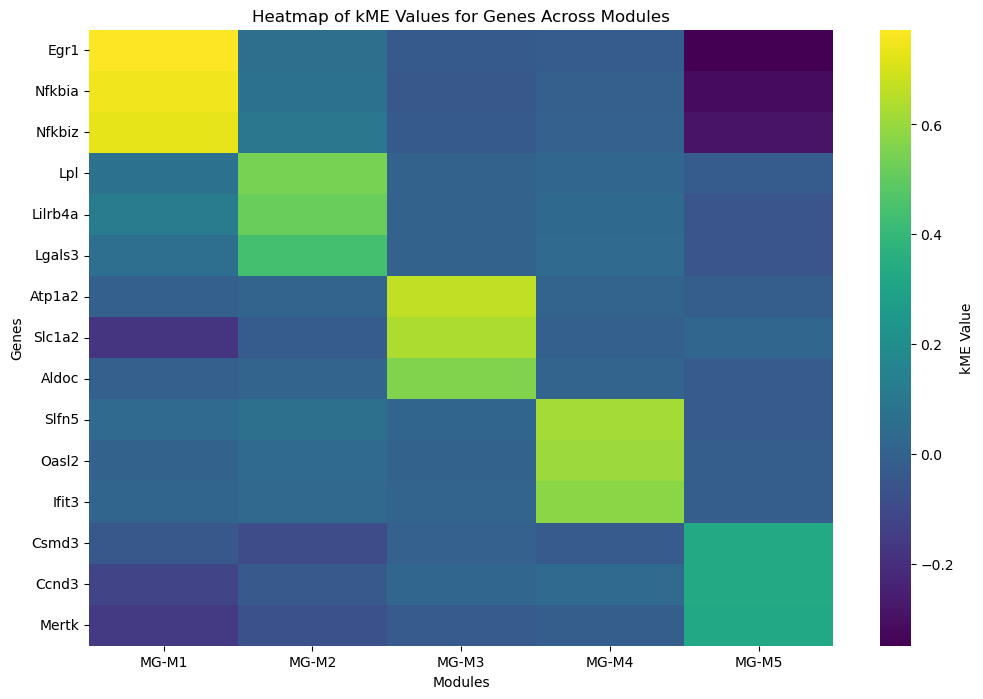

In [27]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

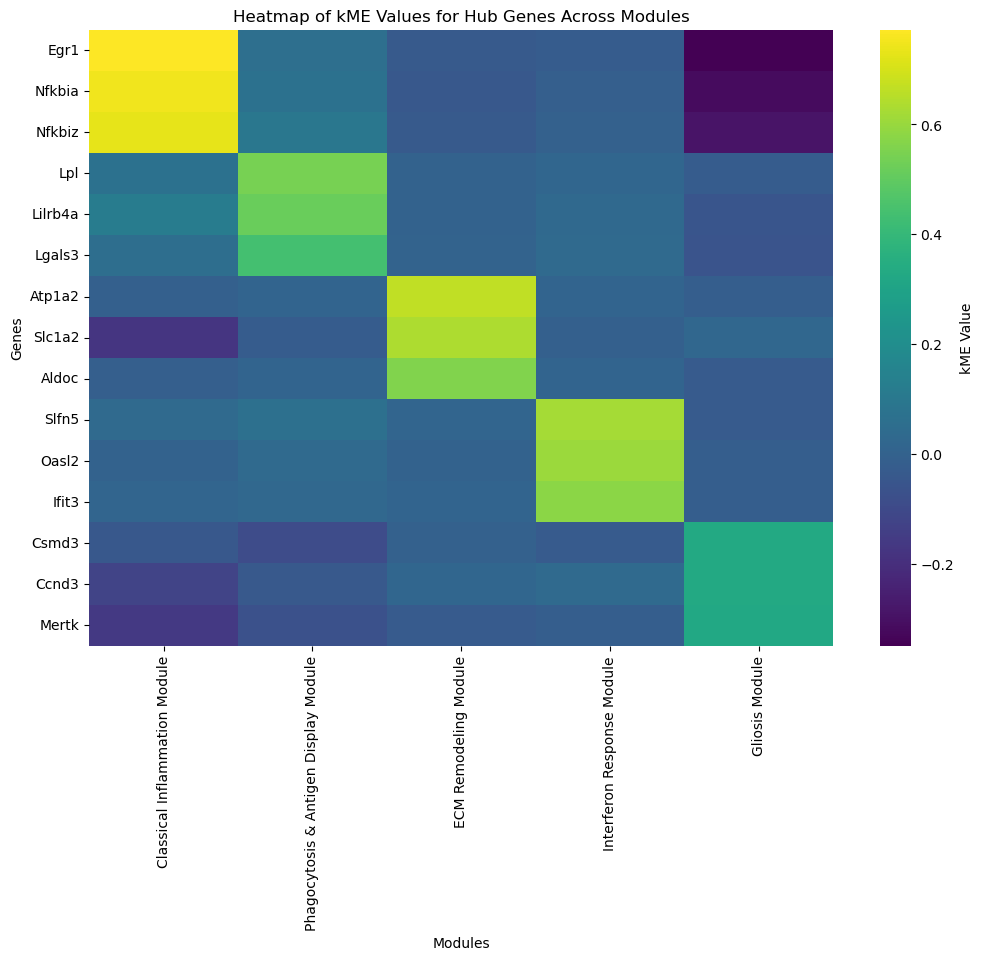

In [28]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Define a dictionary with old module names as keys and new module names as values
module_name_mapping = {
    "MG-M1": "Classical Inflammation Module",
    "MG-M2": "Phagocytosis & Antigen Display Module",
    "MG-M3": "ECM Remodeling Module",
    "MG-M4": "Interferon Response Module",
    "MG-M5": "Gliosis Module"
}

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_name_mapping.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")

plt.show()


### Heatmap: ME across clusters

In [29]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,blue,green,yellow,turquoise,brown
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [34]:
module_color_mapping = {
    "turquoise": "Classical Inflammation Module",
    "brown": "Phagocytosis & Antigen Display Module",
    "green": "ECM Remodeling Module",
    "yellow": "Interferon Response Module",
    "blue": "Gliosis Module"
}

# Replace column names of MEs_df based on the given dictionary
MEs_df.rename(columns=module_color_mapping, inplace=True)

# Display the updated DataFrame
MEs_df.head()

,Gliosis Module,ECM Remodeling Module,Interferon Response Module,Classical Inflammation Module,Phagocytosis & Antigen Display Module
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [30]:
def plot_module_eigengenes_by_cluster(adata, MEs_df, group_by="leiden", agg_func="mean"):
    """
    Plots the average or median of module eigengene values across clusters as a heatmap.

    Parameters:
    - adata: AnnData object
    - MEs_df: DataFrame of module eigengenes, indexed by cell barcodes
    - group_by: Column in adata.obs that defines cluster or group labels
    - agg_func: Aggregation function to use: 'mean' or 'median'
    """

    if agg_func not in ["mean", "median"]:
        raise ValueError("agg_func must be 'mean' or 'median'")

    # Ensure MEs_df index matches adata.obs
    MEs_df = MEs_df.copy()
    if not MEs_df.index.equals(adata.obs_names):
        MEs_df = MEs_df.loc[adata.obs_names]

    # Add cluster information
    MEs_df["cluster"] = adata.obs[group_by].values

    # Aggregate eigengene values by cluster
    if agg_func == "mean":
        agg_df = MEs_df.groupby("cluster").mean()
    else:  # median
        agg_df = MEs_df.groupby("cluster").median()

    # Drop the 'cluster' column if it exists in the result (shouldn’t but just in case)
    agg_df = agg_df.drop(columns=["cluster"], errors="ignore")

    # Reorder columns (clusters) if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        agg_df = agg_df.loc[cluster_order]

    # Plot the heatmap
    fig_width = max(8, agg_df.shape[0] * 1.2)
    fig_height = max(6, agg_df.shape[1] * 0.5)

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        agg_df.T,  # modules on y-axis, clusters on x-axis
        cmap="vlag",
        yticklabels=True,
        xticklabels=True,
        cbar_kws={"label": f"{agg_func.capitalize()} Module Eigengene Value"}
    )

    plt.xlabel("Cluster")
    plt.ylabel("Module")
    plt.title(f"{agg_func.capitalize()} Module Eigengene Expression Across Clusters")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_44912/1153218093.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = MEs_df.groupby("cluster").mean()


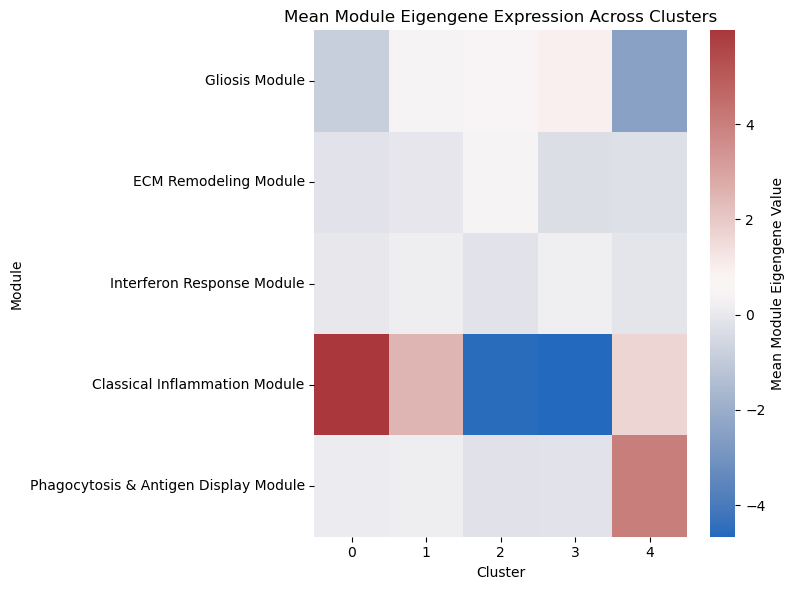

In [35]:
plot_module_eigengenes_by_cluster(
    adata=adata,
    MEs_df=MEs_df,  # Must be indexed by cell barcodes
    group_by=leiden_key,
    agg_func="mean"  # "mean" or "median"
)

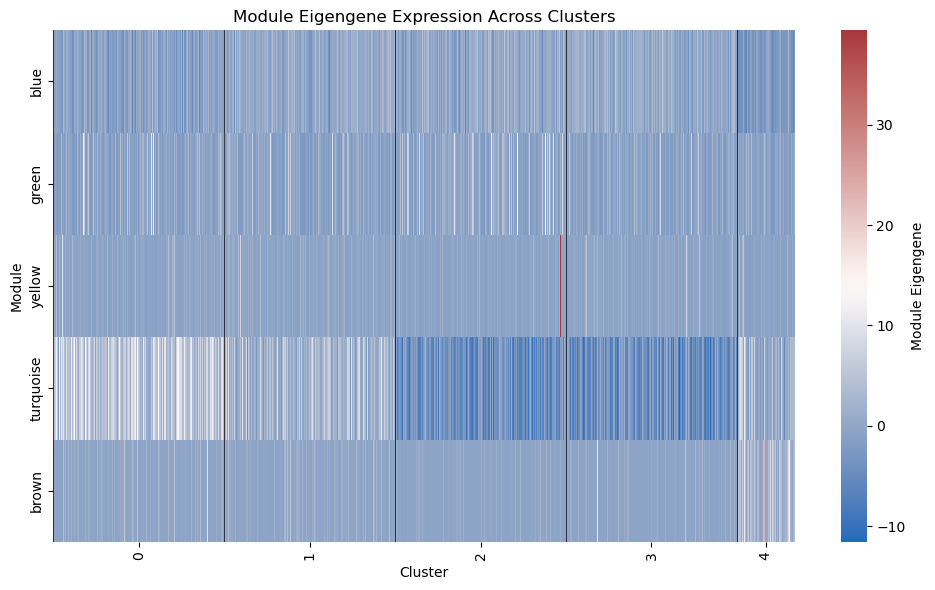

In [41]:
# Match cells and add cluster info
MEs_df["cluster"] = adata.uns[leiden_key]

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells to balance the heatmap
max_cells_per_group = 500
downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
    else:
        sampled_indices = group_indices
    downsampled_indices.extend(sampled_indices)

# Subset AnnData and eigengene dataframe
adata_downsampled = adata[downsampled_indices].copy()
MEs_downsampled = MEs_df.loc[downsampled_indices].copy()

# Sort by cluster for visual clarity
MEs_downsampled["cluster"] = adata_downsampled.obs[group_by].values
MEs_downsampled_sorted = MEs_downsampled.sort_values("cluster")
clusters_sorted = MEs_downsampled_sorted["cluster"]
eigengenes_sorted = MEs_downsampled_sorted.drop(columns="cluster")

# Plot as a heatmap
fig_width = max(10, len(clusters_sorted.unique()) * 2)
fig_height = max(6, len(eigengenes_sorted.columns) * 0.5)

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    eigengenes_sorted.T,
    cmap="vlag",
    yticklabels=True,
    xticklabels=False,
    cbar_kws={"label": "Module Eigengene"}
)

# Mark cluster boundaries
current_pos = 0
xticks = []
xlabels = []
for cluster in clusters_sorted.unique():
    count = (clusters_sorted == cluster).sum()
    xticks.append(current_pos + count // 2)
    xlabels.append(cluster)
    plt.axvline(current_pos, color='black', linewidth=0.5)
    current_pos += count

plt.xticks(xticks, xlabels, rotation=90)
plt.xlabel("Cluster")
plt.ylabel("Module")
plt.title("Module Eigengene Expression Across Clusters")
plt.tight_layout()
plt.show()


In [42]:
top_genes_df

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5,gene_symbol
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611,Egr1
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880,Nfkbia
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948,Nfkbiz
3,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402,Lpl
4,ENSMUSG00000112148,MG-M2,brown,0.119674,0.019395,0.517916,-0.001351,0.030454,-0.055215,Lilrb4a
5,ENSMUSG00000050335,MG-M2,brown,0.050375,0.022079,0.438105,0.001724,0.034987,-0.056614,Lgals3
6,ENSMUSG00000007097,MG-M3,green,-0.009486,0.236036,0.007770,0.665706,0.006892,-0.016427,Atp1a2
7,ENSMUSG00000005089,MG-M3,green,-0.174240,0.278792,-0.027461,0.632778,-0.011341,0.020034,Slc1a2
8,ENSMUSG00000017390,MG-M3,green,-0.013471,0.199158,0.009662,0.561030,0.007734,-0.030248,Aldoc
9,ENSMUSG00000054404,MG-M4,yellow,0.035449,0.016711,0.061497,0.011578,0.622220,-0.031684,Slfn5
